# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [69]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [70]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage =pd.read_csv('/datasets/usage.csv')

In [71]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [72]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [73]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [74]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [75]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [76]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [77]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [78]:
# cantidad de nulos para users
print('Cantidad de nulos:')
print(users.isna().sum())
print('\nPorcentaje de nulos:')
print((users.isna().mean() * 100).round(2))


Cantidad de nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Porcentaje de nulos:
user_id        0.00
first_name     0.00
last_name      0.00
age            0.00
city          11.72
reg_date       0.00
plan           0.00
churn_date    88.35
dtype: float64


In [79]:
# cantidad de nulos para usage
print('Cantidad de nulos:')
print(usage.isna().sum())
print('\nPorcentaje de nulos:')
print((usage.isna().mean() * 100).round(2))

Cantidad de nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Porcentaje de nulos:
id           0.00
user_id      0.00
type         0.00
date         0.12
duration    55.19
length      44.74
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
- En el dataset users, la columna city tiene 11.72% de nulos, se recomienda investigar si existe un patrón y decidir entre imputar con moda o mantener como nulo. La columna churn_date tiene 88.35% de nulos, lo cual es esperado: se interpretarán como usuarios activos y se mantendrá la columna.
En el dataset usage, la columna date tiene 0.12% de nulos, se eliminarán esas filas por ser un caso mínimo. Las columnas duration y length tienen 55.19% y 44.74% de nulos respectivamente, se investigará si el patrón depende del tipo de evento (type); de ser así, los nulos son estructurales y se mantendrán.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [80]:
# explorar columnas numéricas de users
print('Cantidad de user_ids únicos:', users['user_id'].nunique())
print('Total de registros:', len(users))

Cantidad de user_ids únicos: 4000
Total de registros: 4000


In [81]:
print(users['age'].describe())

count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [82]:
print('Valores únicos de age:')
print (sorted(users['age'].unique()))

Valores únicos de age:
[-999, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79]


In [83]:
valor_sentinel = -999
print(f"Registros con valor sentinel: {(users['age'] == valor_sentinel).sum()}")

Registros con valor sentinel: 55


- La columna `user_id` contiene el mismo número de registros que IDs únicos (no hay duplicados).
- La columna `age` tiene cinco registros con un valor sentinel (-999).

In [84]:
print('Cantidad de ids únicos:', usage['id'].nunique())
print('Total de registros', len(usage))

Cantidad de ids únicos: 40000
Total de registros 40000


In [85]:
print('Cantidad de user_ids:', usage['user_id'].nunique())
print('Total de registros', len(usage))

Cantidad de user_ids: 3999
Total de registros 40000


In [86]:
print(usage['user_id'].describe())

count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64


In [87]:
print('Análisis de duration:')
print(usage['duration'].describe())
print("\nAnálisis de length:")  
print(usage['length'].describe())

Análisis de duration:
count    17924.000000
mean         5.202237
std          6.842701
min          0.000000
25%          1.437500
50%          3.500000
75%          6.990000
max        120.000000
Name: duration, dtype: float64

Análisis de length:
count    22104.000000
mean        52.127398
std         56.611183
min          0.000000
25%         37.000000
50%         50.000000
75%         64.000000
max       1490.000000
Name: length, dtype: float64


In [88]:
print('Porcentaje de nulos en duration :')
print((usage['duration'].isna().mean() * 100).round(2))
print('\nPorcentaje de nulos en length:')
print((usage['length'].isna().mean() * 100).round(2))


Porcentaje de nulos en duration :
55.19

Porcentaje de nulos en length:
44.74


- Las columnas `id` y `user_id` muestran comportamientos diferentes. La columna 'id' no tiene duplicados, funcionando como clave primaria. La columna 'user_id' sí tiene duplicados (3999 únicos en 40,000 registros) indicando que cada usuario tiene múltiples registros de uso.
- Las columnas 'duration' y 'length' muestran un patrón de nulos estructural (55.19% y 44.74% respectivamente). Esto sugiere que los valores faltantes dependen del tipo de evento ('type') donde las llamadas tendrán duration, pero no length y viceversa.

In [89]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']


In [90]:
print('Valores únicos en city:')
print (users['city'].unique())

Valores únicos en city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']


In [91]:
# Contar valores nulos
nulos_city = users['city'].isnull().sum()
print(f'Valores NaN en city: {nulos_city}')

Valores NaN en city: 469


In [92]:
# Contar valores sentinel
sentinels_city = (users['city'] == '?').sum()
print(f"Valores sentinel '?' en city: {sentinels_city}")

Valores sentinel '?' en city: 96


In [93]:
# Total de datos faltantes
total_faltantes = nulos_city + sentinels_city
total_registros = len(users)
porcentaje_faltantes = (total_faltantes / total_registros) * 100

print(f"Total datos faltantes en city: {total_faltantes}")
print(f"Porcentaje: {porcentaje_faltantes:.2f}%")

Total datos faltantes en city: 565
Porcentaje: 14.12%


In [94]:
print(f"Diagnóstico completo de city:")
print(f"- Valores nulos originales: {nulos_city}")
print(f"- Valores sentinel '?': {sentinels_city}")
print(f"- Total datos faltantes: {total_faltantes} ({porcentaje_faltantes:.2f}%)")
print(f"- Acción: Reemplazar '?' por NaN para estandarizar")

Diagnóstico completo de city:
- Valores nulos originales: 469
- Valores sentinel '?': 96
- Total datos faltantes: 565 (14.12%)
- Acción: Reemplazar '?' por NaN para estandarizar


In [95]:
print('Valores únicos en plan:')
print(users['plan'].unique())

Valores únicos en plan:
['Basico' 'Premium']


- La columna `city` muestra 7 valores únicos incluyendo 1 valor sentinel "?" y valores ausentes (nan). Las ciudades válidas son: Medellín, CDMX, Bogotá, GDL, MTY, Cali. Esto sugiere problemas de calidad de datos que requieren limpieza.

- La columna `plan` muestra consistencia con solo 2 categorías válidas: 'básico' y 'premium', sin valores problemáticos detectados.

In [96]:
# explorar columna categórica de usage
usage['type'] # completa el código
print('Valores únicos en type:')
print(usage['type'].unique())

Valores únicos en type:
['call' 'text']


- La columna `type` muestra consistencia con solo 2 categorías válidas: 'call' y 'text', sin valores problemáticos detectados.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  

- Se detectó que en las columnas 'age' y 'city' existen valores inválidos y sentinels como se desgloza a continuación:
- En la columna 'age' se detectaron 55 registros con valor sentinel -999 mismos que se reemplazarán con la mediana por ser más robusta antes los outliers y preserva mejor la distribución de edad.
- En la columna 'city' se encontraron 96 valores sentinel '?' que requieren estandarización y 469 valores nulos existentes. Se recomienda reemplazar los valores sentinel por NaN para mantener consistencia en el manejo de datos faltantes totalizando 565 datos faltantes (14.12%)
- No se detectaron problemas en las columnas 'plan' y 'type'.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [97]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [98]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [99]:
# Revisar los años presentes en `reg_date` de users
years_reg_date = users['reg_date'].dt.year.value_counts()
print(years_reg_date)

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


In [100]:
total_2026 = (users['reg_date'].dt.year == 2026).sum()
total_registros = len(users)
porcentaje_invalidos = (total_2026 / total_registros) * 100

print(f"Total años inválidos: {total_2026}")
print(f"Porcentaje: {porcentaje_invalidos:.2f}%")

Total años inválidos: 40
Porcentaje: 1.00%


En `reg_date` se observan 40 registros con año 2026 (1% del total), los cuales representan una fecha imposible dado que los registros llegan hasta el 2024.   

In [101]:
# Revisar los años presentes en `date` de usage
years_date = usage['date'].dt.year.value_counts()
print(years_date)

2024.0    39950
Name: date, dtype: int64


En `date` se encontró que todos los registros válidos pertenecen al año 2024, lo cual es consistente con el rango esperado de los datos.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
En reg_date se identificaron 40 registros con año 2026 (1% del dataset). Al ser menos del 5%, se recomienda eliminar esas filas ya que el impacto es mínimo. En date no se encontraron fechas fuera de rango, por lo que no requiere acción.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [102]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].replace(-999, pd.NA).median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [103]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?',pd.NA)

# Verificar cambios
print(users['city'].unique())

['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']


In [104]:


# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year <= 2024, pd.NaT)

# Verificar cambios
print(users['reg_date'].isna().sum())




40


In [105]:
# Verificar que no quedan fechas futuras
print("Años únicos después de la limpieza:")
print(users['reg_date'].dt.year.value_counts().sort_index())

Años únicos después de la limpieza:
2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


    ### 3.2 Corregir sentinels y fechas imposibles
    **🎯 Objetivo:**  
    Decidir qué hacer con los valores nulos según su proporción y relevancia.
    
    **Instrucciones:**
    - Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
      Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [106]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage.groupby('type')['duration'].count())
print(usage.groupby('type')['duration'].size())

type
call    17908
text       16
Name: duration, dtype: int64
type
call    17908
text    22092
Name: duration, dtype: int64


In [107]:
usage.isna().groupby(usage['type'])['duration'].sum()

type
call        0
text    22076
Name: duration, dtype: int64

In [108]:
usage['duration'].isna().sum()

22076

In [109]:
resultado = usage.groupby('type')['duration'].agg(lambda x: x.isnull().mean().round(1)) 
print(resultado)

type
call    0.0
text    1.0
Name: duration, dtype: float64


In [110]:

# Verificación MAR en usage (Missing At Random) para length


In [111]:
resultado = usage.groupby('type')['length'].agg(lambda x: x.isnull().mean().round(1)) 
print(resultado)

type
call    1.0
text    0.0
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
El resultado diagnósitco indica que Los nulos en duration y length son MNAR; es decir, no son aleatorios sino que dependen de la naturaleza del evento. 'duration' solo existe en llamadas y 'length' solo en mensajes, por lo que los nulos son estructurales y se dejan como están.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [112]:

# Columnas auxiliares

usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'is_text': 'sum','is_call': 'sum','duration': 'sum'}). reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [113]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes','is_call': 'cant_llamadas','duration': 'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [114]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = user_profile  = usage_agg.merge(users, on='user_id')
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [115]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.729432,5.524381,4.478120,23.317054,48.138285
std,1154.898108,2.358416,2.144238,18.168095,17.691541
min,10000.000000,0.000000,0.000000,0.000000,18.000000
25%,10999.500000,4.000000,3.000000,11.120000,33.000000
50%,12000.000000,5.000000,4.000000,19.780000,48.000000
75%,12999.500000,7.000000,6.000000,31.415000,63.000000
max,13999.000000,17.000000,15.000000,155.690000,79.000000


In [116]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

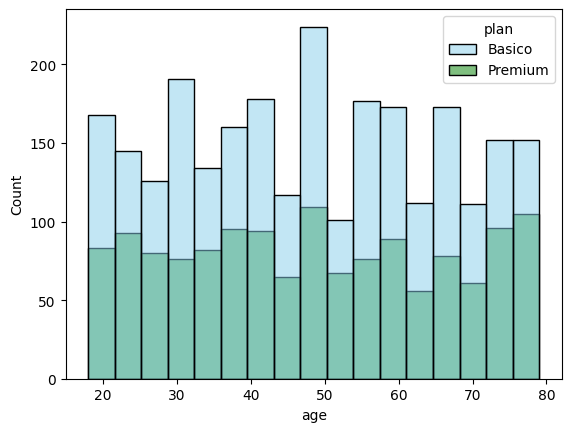

In [117]:

# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'])
plt.show()


💡Insights: 
- La distribución de edad es aproximadamente uniforme entre 20 y 80 años, con un ligero pico alrededor de los 50. Se observa que en el rango de 70 a 80 años hay una mayor proporción de usuarios Premium, lo cual podría indicar que los adultos mayores tienen mayor capacidad económica para costear planes más altos. Este segmento representa una oportunidad para optimizar la oferta comercial dirigida a usuarios de mayor edad, mientras que para usuarios jóvenes, que podrían estar en etapas tempranas de generación de ingresos, podría ser relevante reforzar la propuesta de valor del plan Básico.

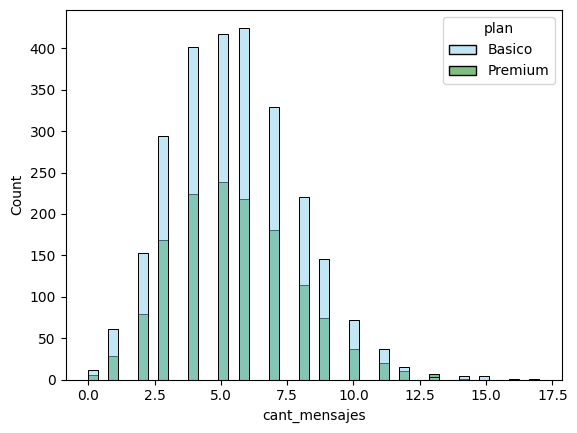

In [118]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])
plt.show()

💡Insights: 
- La distribución de cant_mensajes es sesgada a la derecha, con la mayoría de usuarios enviando entre 4 y 6 mensajes. Los usuarios Premium se concentran proporcionalmente más en ese rango medio-alto, lo que sugiere que el mayor acceso a datos del plan Premium incentiva un mayor uso de mensajería. Para la empresa, esto representa una oportunidad de promover upgrades a Premium entre usuarios Básico con alto volumen de mensajes, ofreciendo promociones de datos como incentivo.

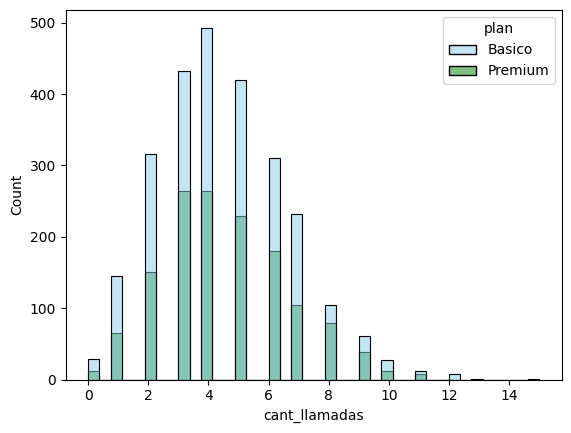

In [119]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', 
palette=['skyblue', 'green'])
plt.show()


💡Insights: 
- Distribución sesgada a la derecha. Se observa que os usuarios Premium tienden a realizar más llamadas que los Básico, patrón consistente con el histograma de cant_mensajes. Esto confirma la hipótesis de que los usuarios Premium aprovechan más el servicio por lo que pagan, lo que refuerza la oportunidad de promover upgrades entre usuarios Básico con alto volumen de uso.

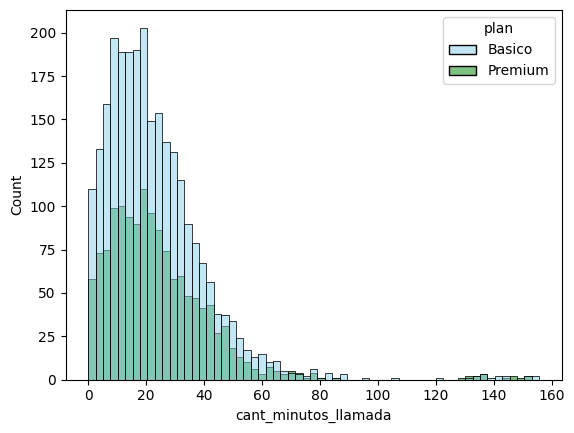

In [120]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada',hue='plan',palette=['skyblue', 'green'])
plt.show()

💡Insights: 
- Distribución sesgada a la derecha con mayor concentración alrededor de los 20 minutos. La duración de llamadas es similar entre ambos planes, lo que sugiere que el plan no influye en cuánto tiempo habla un usuario sino en la frecuencia con la que llama. Esto podría indicar que los usuarios Básico están limitados por su plan, lo que refuerza la oportunidad de promover upgrades a Premium.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

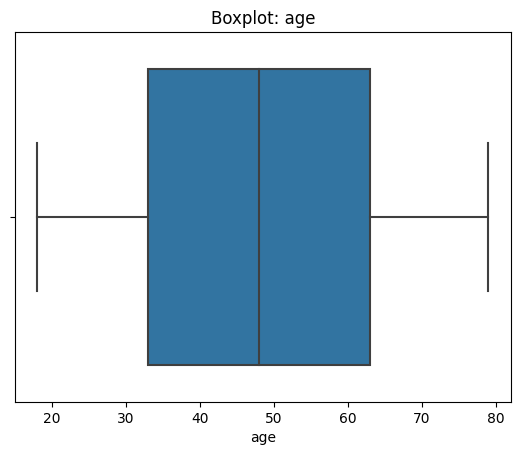

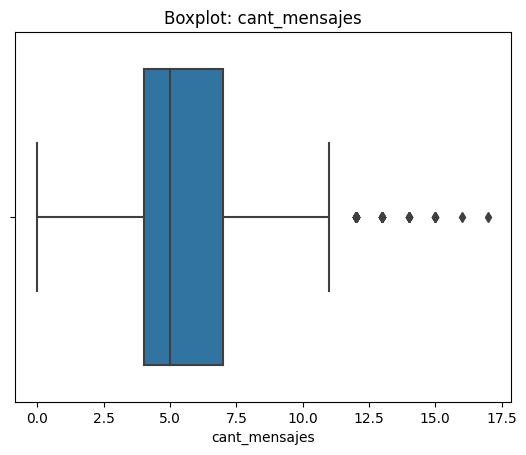

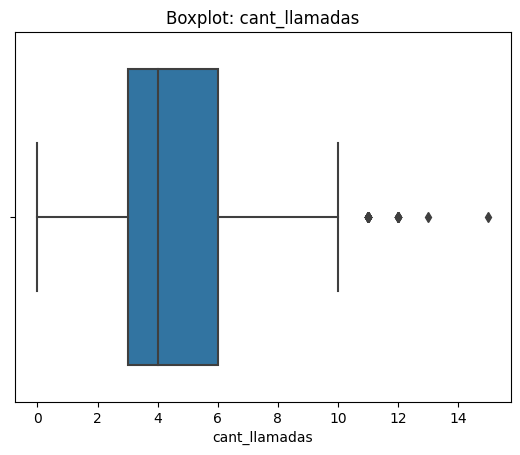

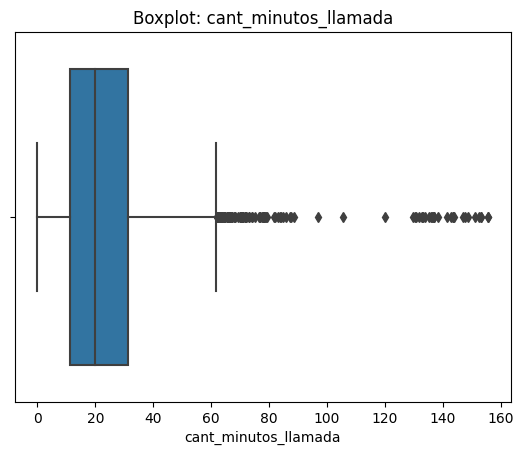

In [121]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col, hue='plan')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: Tanto la caja como los bigotes están equilibrados en el rango IQR. No se presentan outliers.
- cant_mensajes: Los bigotes están equilibrados con relación al IQR, con la mediana cargada hacia 5 mensajes. Se observan outliers del lado derecho a partir de ~11 mensajes, representando usuarios que envían una cantidad significativamente alta de mensajes.
- cant_llamadas: La mediana está cargada hacia 4 llamadas con el bigote máximo más largo. Se observan outliers del lado derecho a partir de ~11 llamadas, representando usuarios con uso elevado del servicio.
- cant_minutos_llamada: La mediana se encuentra alrededor de los 20 minutos con el IQR ligeramente sesgado a la izquierda. El bigote máximo llega aproximadamente a los 70 minutos, a partir de donde se observan numerosos outliers representando usuarios con volumen de llamadas significativamente mayor al resto.
- En los tres casos los outliers aparecen únicamente del lado derecho, lo que sugiere un segmento de usuarios con uso alto del servicio que podría representar clientes de alto valor para la empresa.

In [122]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile [col].quantile(0.75)
    IQR = Q3-Q1
    limite_superior = Q3 + 1.5 * IQR
    print(f"{col} - Límite superior: {limite_superior:.2f}")

cant_mensajes - Límite superior: 11.50
cant_llamadas - Límite superior: 10.50
cant_minutos_llamada - Límite superior: 61.86


In [123]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 

- cant_mensajes: los outliers se encuentran únicamente de lado máximo comenzando a partir de 11.5 mensajes hasta 17 mensajes en su nivel máximo representando a usuarios que tienen gran uso del servicio de mensajería por lo que se deben mantener.
- cant_llamadas: los outliers comienzan en 10.5 llegando a un máximo de 15 llamadas, rpresentando a usuarios que tienen gran uso del servicio de llamadas por lo que se deben mantener.
- cant_minutos_llamada: los outliers comienzan en 61.86 minutos llegando a un máximo de 155.69 minutos, representando usuarios con un volumen de llamadas significativamente alto. Al ser valores posibles dentro del contexto de telecomunicaciones, se deben mantener.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [124]:
# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas'] <5) & (user_profile['cant_mensajes'] <5),
    (user_profile['cant_llamadas'] <10) & (user_profile['cant_mensajes']<10)
]

valores = [
    'Bajo uso',
    'Uso medio'
]

user_profile['grupo_uso'] = np.select(condiciones, valores, default='Alto uso')

In [125]:
user_profile['grupo_uso'].value_counts()

Uso medio    2943
Bajo uso      778
Alto uso      278
Name: grupo_uso, dtype: int64

In [126]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [127]:
# Crear columna grupo_edad
condiciones = [
    (user_profile['age'] <30),
    (user_profile['age'] <60)
]

valores = [
    'Joven',
    'Adulto'
]

user_profile['grupo_edad'] = np.select(condiciones, valores, default='Adulto Mayor')


In [128]:
user_profile['grupo_edad'].value_counts()

Adulto          2017
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [129]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

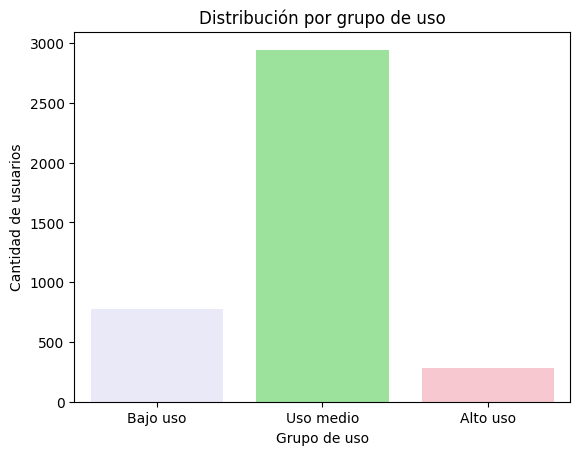

In [134]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', 
              order=['Bajo uso', 'Uso medio', 'Alto uso'],
              palette=['lavender', 'lightgreen', 'pink'])
plt.title('Distribución por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show() 

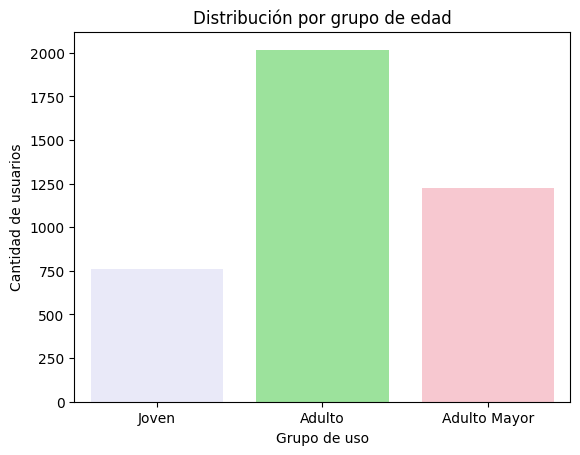

In [135]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', 
              order=['Joven', 'Adulto', 'Adulto Mayor'],
              palette=['lavender', 'lightgreen', 'pink'])
plt.title('Distribución por grupo de edad')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show() 


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Se encontraron diferentes problemas en dos dataframes. En el dataframe de users, se encontró que 469 de los valores eran nulos (11.72%) y 96 valores eran sentinel ('?'), sumando 565 registros faltantes (14.13%). Se reemplazaron los sentinel por nulos. Así mismo, se encontró que en la columna de 'age' se encontraron 55 registros con valor sentinel -999 (1.37%), mismo que se reemplazaron con la mediana por ser más robusta ante outliers. Finalmente, se encontró que para la columna 'reg_date' habían 40 registros con año 2026 (1%), fecha imposible dado que los datos llegan hasta 2024. Se marcaron como nulos. Por otro lado, para el dataframe de usage se encontró que para la columna 'date' habían 50 registros nulos (0.12%) mismos que se eliminaron por ser un caso mínimo. Finalmente se encontró que en las columnas 'duration' y 'length' había 55.19% y 44.74% de nulos respectivamente. Dado que dichos nulos dependen del tipo de evento, se mantuvieron al confirmarse que son MNAR.

🔍 **Segmentos por Edad**
Se identificó que 760 usuarios son jóvenes (19%), 2017 son adultos (50.44%) y 1222 son adultos mayores (30.56%). La distribución es aproximadamente uniforme entre 20 y 80 años, con los jóvenes concentrándose más en el plan Básico y los adultos mayores mostrando mayor proporción de plan Premium.

📊 **Segmentos por Nivel de Uso**
2943 usuarios son de uso medio (73.59%), 778 de bajo uso (19.45%) y 278 de alto uso (6.95%). Los usuarios Premium tienden a enviar más mensajes y realizar más llamadas que los Básico. La duración de las llamadas es similar entre ambos planes, lo que indica que el plan influye en la frecuencia de uso pero no en el tiempo por llamada.


➡️ Esto sugiere que los segmentos más valiosos para ConnectaTel son los usuarios Premium y los de Alto uso, ya que generan mayor consumo del servicio. Los outliers encontrados en cant_mensajes, cant_llamadas, y cant_minutos_llamada representan usuarios con uso significativamente mayor al promedio, lo que los convierte en clientes de alto valor que merecen atención especial para su retención. Adicionalmente, dado que la mayoría de usuarios se concentra en el plan Básico y uso medio, existe una oportunidad importante de migrarlos hacia planes superiores.


💡 **Recomendaciones**
- Crear una campaña de upgrade dirigida a usuarios Básico que superen X mensajes o llamadas al mes, ofreciendo un descuento en el primer mes de Premium.
- Diseñar promociones exclusivas para Adultos Mayores que ya tienen plan Premium para fidelizarlos, como descuentos por antigüedad o beneficios adicionales.
- Desarrollar ofertas atractivas para jóvenes en plan Básico, como bonos de datos adicionales o promociones de equipos, para engancharlos a largo plazo.
- Implementar un programa de lealtad para usuarios de Alto uso y outliers, reconociendo su consumo elevado con beneficios exclusivos para evitar su deserción.
Crear campañas de reactivación para usuarios de Bajo uso con promociones que incentiven mayor consumo del servicio.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`